In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential

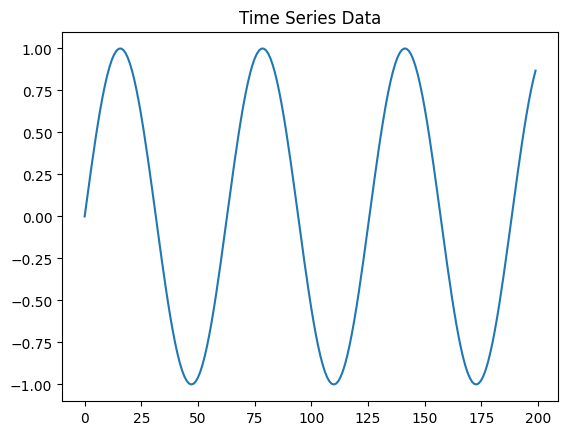

In [2]:
time = np.arange(200)
data = np.sin(time * 0.1)

plt.plot(data)
plt.title("Time Series Data")
plt.show()

In [6]:
X = []
Y = []

for i in range(len(data) - 10):
    X.append(data[i:i+10])
    Y.append(data[i+10])

X = np.array(X)
Y = np.array(Y)

print("X:", X.shape)
print("Y:", Y.shape)

X: (190, 10)
Y: (190,)


In [7]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]

X_train = X_train.reshape(-1, 10, 1)
X_test = X_test.reshape(-1, 10, 1)

In [9]:
ffnn = Sequential([
      layers.Flatten(input_shape=(10,1)),
          layers.Dense(32, activation='relu'),
              layers.Dense(16, activation='relu'),
                  layers.Dense(1)
                  ])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
ffnn.compile(
      optimizer='adam',
          loss='mse'
          )


In [11]:
ffnn.fit(
      X_train,
          Y_train,
              epochs=20,
                  verbose=0
                  )

print("Feedforward NN training completed")


Feedforward NN training completed


In [12]:
birnn = Sequential([
      layers.Bidirectional(
              layers.SimpleRNN(32),
                      input_shape=(10,1)
                          ),
                              layers.Dense(16, activation='relu'),
                                  layers.Dense(1)
                                  ])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
birnn.compile(
      optimizer='adam',
          loss='mse'
          )


In [14]:
birnn.fit(
      X_train,
          Y_train,
              epochs=20,
                  verbose=0
                  )

print("BiRNN training completed")


BiRNN training completed


In [15]:
ffnn_loss = ffnn.evaluate(X_test, Y_test, verbose=0)
birnn_loss = birnn.evaluate(X_test, Y_test, verbose=0)

print("Feedforward NN MSE:", ffnn_loss)
print("BiRNN MSE:", birnn_loss)

Feedforward NN MSE: 0.010319353081285954
BiRNN MSE: 0.0019317773403599858


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


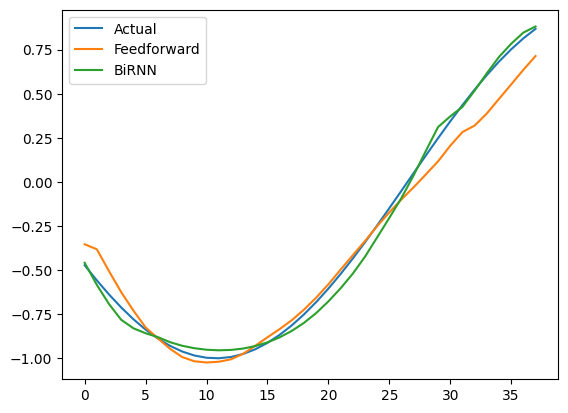

In [16]:
ffnn_pred = ffnn.predict(X_test)
birnn_pred = birnn.predict(X_test)

plt.plot(Y_test, label="Actual")
plt.plot(ffnn_pred, label="Feedforward")
plt.plot(birnn_pred, label="BiRNN")
plt.legend()
plt.show()